In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib
from functools import partial

In [87]:
import eoc_eod_functions
import analytical_functions
importlib.reload(analytical_functions)
importlib.reload(eoc_eod_functions)
from eoc_eod_functions import *
from analytical_functions import *

In [88]:
## Load MetaData
cap_tests = pd.read_excel('/home/tamoghna/Matlab/Mehran_stuff/Metadata_and_Code/00_Data/00_Metadata/Capacity_Tests.xlsx')
systems_md = pd.read_excel('/home/tamoghna/Matlab/Mehran_stuff/Metadata_and_Code/00_Data/00_Metadata/Metadata_Systems.xlsx')

In [86]:
systems_md.head(6)

,ID,Capacity_nominal_in_Ah,Voltage_nominal_in_V,Energy_nominal_in_kWh,Energy_usable_datasheet_in_kWh,Cell_number_in_series,Cell_number_in_parallel,Cell_number,Inverter_nominal_power,Manufacturer,Chemistry,Chemistry_detail,Date_storage_system_installation,Date_measurement_system_installation
0,1,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1426201200,1436486400
1,2,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1418943600,1450706306
2,3,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1431640800,1464048000
3,4,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1453244400,1466546400
4,5,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1416610800,1471384800
5,6,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1411336800,1473685200


In [ ]:
op_datapath_6 = '/home/tamoghna/Matlab/Mehran_stuff/Metadata_and_Code/00_Data/01_Operational_Data/Data_ID_06/06'
op_datapath_7 = '/home/tamoghna/Matlab/Mehran_stuff/Metadata_and_Code/00_Data/01_Operational_Data/Data_ID_07/07'

y=2020
m=9
sample_data = pd.read_csv(f'{op_datapath_6}/{y}_0{m}_System_ID_06.csv')
# Apply time processing to get seconds and time in datetime format
sample_data = process_time(sample_data)


In [49]:
# Scale to cell level
sample_data = cell_level_scaling(sample_data, systems_md, cell_id=6)

In [50]:
_, cell_capacity_ah = cell_level_info(systems_md, cell_id=6)

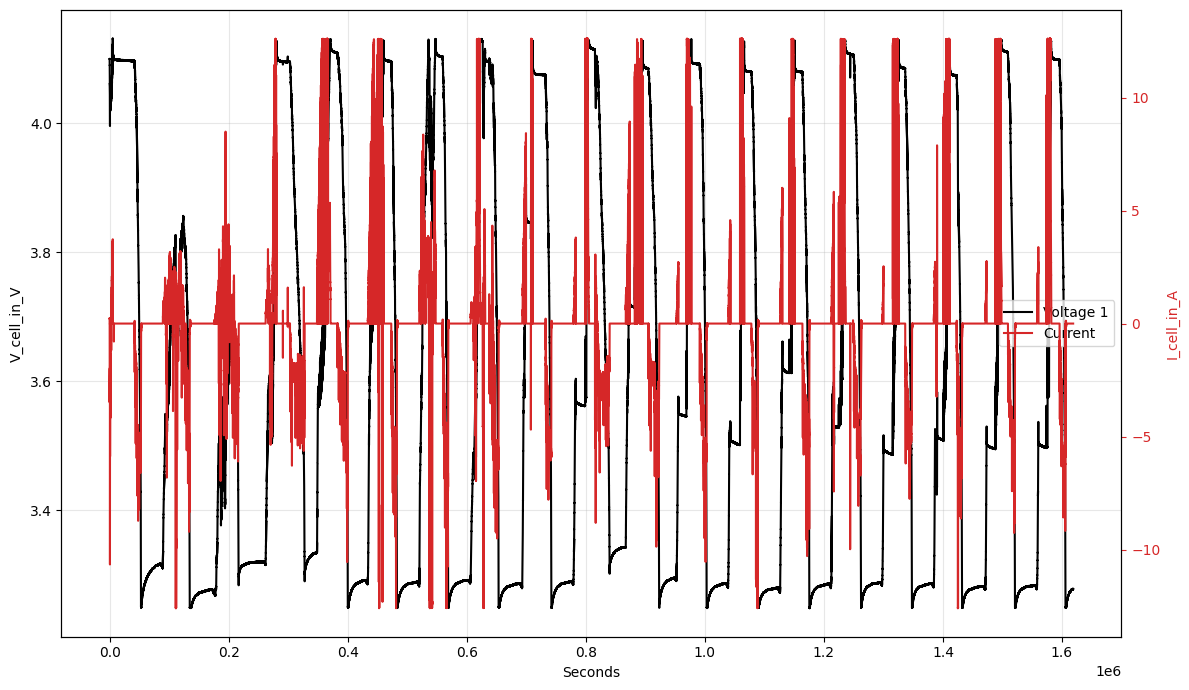

In [51]:
column_map = {1: 'V_cell_in_V', 2: 'I_cell_in_A'}
plot_multi_axis(sample_data, column_map, ('Voltage 1', 'Current'), x='Seconds')
plt.show()

## SOC Calculaton stuff

In [52]:
max_V = sample_data['V_cell_in_V'].max()
min_V = sample_data['V_cell_in_V'].min()
print(f'Max Voltage: {max_V:.2f} V, Min Voltage: {min_V:.2f} V')

Max Voltage: 4.13 V, Min Voltage: 3.25 V


In [53]:
# Find time corresponding times to max and min V which I can associate with the 100 and 0 SOC points for the coulomb counting method
max_V_time = sample_data[sample_data['V_cell_in_V'] == max_V]['Seconds'].iloc[0]
min_V_time = sample_data[sample_data['V_cell_in_V'] == min_V]['Seconds'].iloc[0]
print(f'Time at Max Voltage: {max_V_time} s, Time at Min Voltage: {min_V_time} s')

Time at Max Voltage: 5302.0 s, Time at Min Voltage: 1176166.0 s


In [95]:
# Use these times as anchor points for the coulomb counting method to get SOC profile over the entire time range
soc_vmin = coulomb_count_bidirectional(
    sample_data, 
    capacity_ah=cell_capacity_ah, 
    anchor_time=min_V_time,
    anchor_soc=.1,
    clip_soc=False
)

soc_vmax = coulomb_count_bidirectional(
    sample_data, 
    capacity_ah=cell_capacity_ah, 
    anchor_time=max_V_time,
    anchor_soc=.8,
    clip_soc=False
)

In [96]:
sample_data['SOC_vmin'] = soc_vmin
sample_data['SOC_vmax'] = soc_vmax

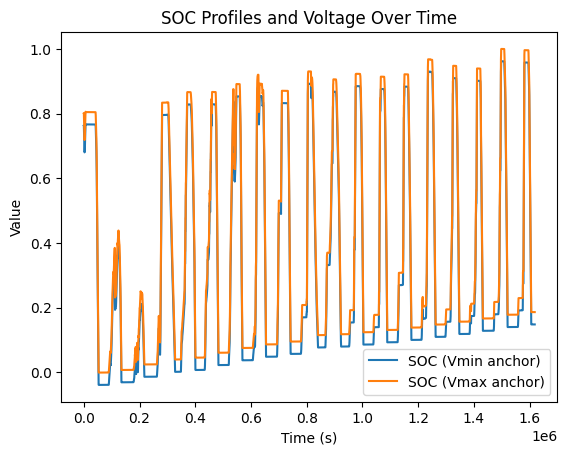

In [97]:
plt.plot(sample_data['Seconds'], sample_data['SOC_vmin'], label='SOC (Vmin anchor)')
plt.plot(sample_data['Seconds'], sample_data['SOC_vmax'], label='SOC (Vmax anchor)')
# plt.plot(sample_data['Seconds'], sample_data['V_cell_in_V'], label='Voltage')
plt.xlabel('Time (s)')
plt.ylabel('Value')
plt.title('SOC Profiles and Voltage Over Time')
plt.legend()
plt.show()

In [85]:
sample_data[['I_in_A', 'I_cell_in_A']].head()

,I_in_A,I_cell_in_A
0,0.228455,0.228455
1,0.228456,0.228456
2,0.228458,0.228458
3,0.228460,0.228460
4,0.228461,0.228461


### Simple implementation: Calculate the throughput between the max and min voltage for each month and see how it looks

In [ ]:
# Try to calculate on Full dataset
# This will calculate max and min voltage and their corresponding timestamps
def vmax_vmin(df):
    max_V = df['V_cell_in_V'].max()
    min_V = df['V_cell_in_V'].min()
    max_V_time = df[df['V_cell_in_V'] == max_V]['Seconds'].iloc[0]
    min_V_time = df[df['V_cell_in_V'] == min_V]['Seconds'].iloc[0]
    return max_V, min_V, max_V_time, min_V_time

In [ ]:

full_data_vmax_vmin = load_and_operate(
    folder_path=op_datapath_6,
    start_year=2022,
    end_year=2022,
    cellID=6,
    month=None,
    print_missing=True,
    operation=vmax_vmin
)